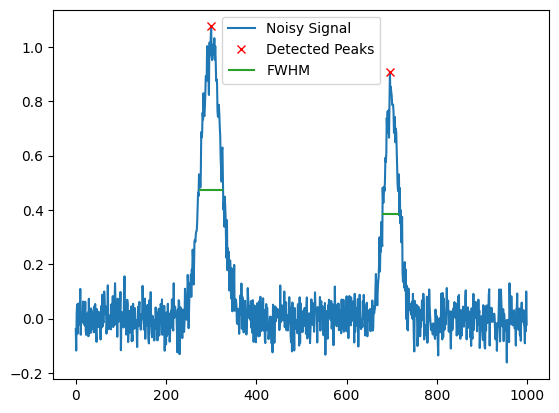

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

# Generate simulated data: Two Gaussian peaks with some random noise
x = np.linspace(0, 100, 1000)
# Create peaks at x=30 and x=70
y = np.exp(-((x - 30) ** 2) / 10) + 0.8 * np.exp(-((x - 70) ** 2) / 5) 
# Add noise to the signal
y += np.random.normal(0, 0.05, x.size)

# 1. Find peaks
# Require a minimum height of 0.3 and a prominence of 0.2
# Parameters: (signal_array, height_threshold, prominence_threshold)
peaks, properties = find_peaks(y, height=0.3, prominence=0.2)

# 2. Calculate peak widths (FWHM: rel_height=0.5)
# Parameters: (signal_array, peak_indices, relative_height)
widths, width_heights, left_ips, right_ips = peak_widths(y, peaks, rel_height=0.5)

# 3. Visualize the results
plt.plot(y, label='Noisy Signal')
plt.plot(peaks, y[peaks], "x", label='Detected Peaks', color='red')

# Draw the width lines using horizontal lines (hlines)
# Parameters: (y_coordinates, x_start, x_end, color)
plt.hlines(width_heights, left_ips, right_ips, color="C2", label='FWHM')

plt.legend()
plt.show()